In [2]:
from IPython.display import Image, display
from typing import Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

In [3]:
model = ChatOpenAI(model_name="gpt-5-nano")
checkpointer = MemorySaver()

In [4]:
class State(MessagesState):
  summary: str

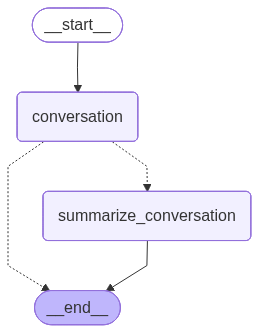

In [5]:
def call_model(state: State, config: RunnableConfig):
    
    # Get summary if it exists
    summary = state.get("summary", "")

    # If there is summary, then we add it
    if summary:
        
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    response = model.invoke(messages, config)
    return {"messages": response}

def summarize_conversation(state: State):
    
    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt 
    if summary:
        
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
        
    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# Determine whether to end or summarize the conversation
def should_continue(state: State)-> Literal ["summarize_conversation",END]:
    
    """Return the next node to execute."""
    
    messages = state["messages"]
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
    
    # Otherwise we can just end
    return END

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
for chunk in graph.stream({"messages": [HumanMessage(content="Mk")]}, config, stream_mode="updates"):
    print(chunk)

{'conversation': {'messages': AIMessage(content="Got it. What would you like to do? A few options:\n- Explain a concept or topic\n- Solve a problem or write/code something\n- Draft, edit, or summarize text\n- Brainstorm ideas or plans\n- Get recommendations (books, tools, etc.)\n- Help with tasks or questions you have\n\nTell me your goal and any constraints, and how you'd like the result formatted.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 346, 'prompt_tokens': 7, 'total_tokens': 353, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 256, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DKmdCRHoIQjdUFDvZ3vVJ0pjqNF4z', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d0173-f550-7ef0-bb0

In [7]:
# Start conversation
for chunk in graph.stream({"messages": [HumanMessage(content="hi! I'm Lance")]}, config, stream_mode="updates"):
    chunk['conversation']["messages"].pretty_print()

================================== Ai Message ==================================

Nice to meet you, Lance! What would you like to work on today? Here are some ways I can help:

- Explain a concept or topic (in plain terms or with depth)
- Solve a problem or write code (or fix bugs)
- Draft, edit, or summarize text
- Brainstorm ideas or plan something (projects, trips, events)
- Get recommendations (books, tools, strategies)
- Help with tasks or questions (step-by-step guides, checklists)

Tell me your goal and any constraints, and how you’d like the result formatted. If you have a task ready, feel free to share and I’ll jump in.


In [8]:
# Start conversation, again
config = {"configurable": {"thread_id": "2"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm Muthu")
for event in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    for m in event['messages']:
        m.pretty_print()
    print("---"*25)

================================ Human Message =================================

hi! I'm Muthu
---------------------------------------------------------------------------
================================ Human Message =================================

hi! I'm Muthu
================================== Ai Message ==================================

Hi Muthu! Nice to meet you. How can I help today? Tell me what you’d like to do—whether it’s answering questions, helping with writing or code, brainstorming ideas, planning something, or just chatting.
---------------------------------------------------------------------------


In [9]:
config = {"configurable": {"thread_id": "3"}}
input_message = HumanMessage(content="Tell me about the crew AI")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    print(f"Node: {event['metadata'].get('langgraph_node','')}. Type: {event['event']}. Name: {event['name']}")

Node: . Type: on_chain_start. Name: LangGraph
Node: conversation. Type: on_chain_start. Name: conversation
Node: conversation. Type: on_chat_model_start. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. N

In [10]:
node_to_stream = 'conversation'
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="Tell me about the crew AI")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        print(event["data"])

{'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019d0174-693f-7430-a996-510119eaf9c6', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content='Could', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019d0174-693f-7430-a996-510119eaf9c6', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' you', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019d0174-693f-7430-a996-510119eaf9c6', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' clarify', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019d0174-693f-7430-a996-510119eaf9c6', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' what', additional_kwargs={}, response_metadata={'model_provider': 'openai'},

In [11]:
config = {"configurable": {"thread_id": "5"}}
input_message = HumanMessage(content="Tell me about the crewAI")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        data = event["data"]
        print(data["chunk"].content, end="|")

|I|’m| not| sure| which| “|Crew|AI|”| you| mean|.| Do| you| have| a| specific| product|,| company|,| or| concept| in| mind|?| If| you| can| share| a| link| or| a| bit| more| context|,| I| can| tailor| the| information|.| In| the| meantime|,| here| are| a| few| ways| people| use| the| term| and| what| such| a| system| typically| does|:

|What| “|Crew| AI|”| can| refer| to|
|-| An| AI|-powered| workforce|/|crew| management| platform|:| software| that| helps| organisations| schedule|,| assign|,| and| manage| teams| or| “|cre|ws|”| across| shifts|,| projects|,| or| locations|.
|-| A| product| or| startup| name|:| there| are| or| could| be| multiple| products| with| similar| names| focusing| on| AI|-assisted| crew| planning|,| rost|ering|,| or| operations|.
|-| A| generic| concept|:| using| AI| to| optimize| crew| allocation|,| fatigue| risk|,| skills| matching|,| and| cost| control| in| industries| with| large|,| rotating| work|forces|.

|Common| features| you|’d| expect|
|-| Smart| rost|e